# Prompt Score Distributions vs Expert Scores

Compares the **initial** (un-optimised) severity prompts (Harsh / Balanced / Lenient = bad / middle / good) against the **optimised** evaluators (score-only `no_experts`, EGPO-selected indices used by the real pipeline: electronic `[1,1,2]`, clothing `[2,2,0]`, food `[0,2,0]`) on the human/expert-annotated test bundles.

Outputs: the stacked **Electronic / Clothing / Food** distributions figure and a paper-ready **inter-rater agreement** table (Pearson r & ICC). Just run all cells.

In [1]:
# 1. Dependencies (Colab already has numpy/pandas/matplotlib/scipy)
!pip -q install openpyxl statsmodels

In [2]:
# 2. Data: sparse clone of the score pkls (1_EGPO/filter_results) + expert annotations (Bundle Annotations)
import os
if not os.path.isdir("/content/LLM4BEAR"):
    !git clone --depth 1 --filter=blob:none --sparse https://github.com/anon5159753/LLM4BEAR.git /content/LLM4BEAR
    !cd /content/LLM4BEAR && git sparse-checkout set "1_EGPO" "Bundle Annotations"
else:
    print("/content/LLM4BEAR already present")

# Point the analysis at the clone (falls back to a local checkout if present).
REPO = "/content/LLM4BEAR" if os.path.isdir("/content/LLM4BEAR") else "LLM4BEAR"
print("REPO =", REPO)

Cloning into '/content/LLM4BEAR'...
remote: Enumerating objects: 81, done.
remote: Counting objects: 100% (81/81), done.
remote: Compressing objects: 100% (68/68), done.
Receiving objects: 100% (81/81), 44.28 KiB | 1.64 MiB/s, done.
remote: Total 81 (delta 10), reused 76 (delta 10), pack-reused 0 (from 0)
Resolving deltas: 100% (10/10), done.
remote: Enumerating objects: 1, done.
remote: Counting objects: 100% (1/1), done.
remote: Total 1 (delta 0), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (1/1), 9.97 KiB | 4.98 MiB/s, done.
remote: Enumerating objects: 113, done.
remote: Counting objects: 100% (113/113), done.
remote: Compressing objects: 100% (99/99), done.
remote: Total 113 (delta 14), reused 112 (delta 14), pack-reused 0 (from 0)
Receiving objects: 100% (113/113), 2.79 MiB | 13.60 MiB/s, done.
Resolving deltas: 100% (14/14), done.
REPO = /content/LLM4BEAR


In [3]:
# 3. === Analysis library (self-contained) ===
import os, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm

FR = f"{REPO}/1_EGPO/filter_results"
ROLES = ["bad", "middle", "good"]                      # == Harsh / Balanced / Lenient
LABEL = {"bad": "Harsh", "middle": "Balanced", "good": "Lenient"}
PAIRS = [("bad", "middle"), ("middle", "good"), ("bad", "good")]
PAIR_LABEL = {("bad", "middle"): "Harsh–Balanced", ("middle", "good"): "Balanced–Lenient",
              ("bad", "good"): "Harsh–Lenient"}

# domain -> (test-row slice, canonical no_experts prompt indices [bad,middle,good])
DOMAINS = {
    "electronic": (slice(72, 137), [1, 1, 2]),
    "clothing":   (slice(80, 151), [2, 2, 0]),
    "food":       (slice(80, 150), [0, 2, 0]),
}

# Colorblind-safe (Okabe-Ito): initial vs optimised are the two entities; expert is neutral reference.
C_INIT, C_OPT, C_EXPERT = "#E69F00", "#0072B2", "#444444"
FIG_DIR, OUT_DIR = "figures", "output"
os.makedirs(FIG_DIR, exist_ok=True); os.makedirs(OUT_DIR, exist_ok=True)


def _scores(char):
    with open(f"{FR}/{char}.pkl", "rb") as f:
        _reward, _responses, _verdicts, scores = pickle.load(f)
    return scores


def load_scores(dom):
    sl, idx = DOMAINS[dom]
    true = pd.read_excel(f"{REPO}/Bundle Annotations/{dom}_annotations.xlsx").iloc[sl, 2].tolist()
    initial = {r: _scores(f"{dom}_dataset_initial_{r}_importance_prompt") for r in ROLES}
    optim = {r: _scores(f"{dom}_dataset_{r}_evaluator_{dom}_importance_no_experts_{ix}")
             for r, ix in zip(ROLES, idx)}
    return true, initial, optim


def _purge(a, b):
    pa, pb = [], []
    for x, y in zip(a, b):
        if x is not None and y is not None:
            pa.append(float(x)); pb.append(float(y))
    return pa, pb


def icc_a1(a_raw, b_raw):
    """ICC(A,1) absolute-agreement between two raters (as in Determining_Best_Prompts)."""
    a, b = _purge(a_raw, b_raw)
    if len(a) < 3:
        return {"ICC": np.nan, "Pearson": np.nan, "Spearman": np.nan}
    n = len(a)
    data = pd.DataFrame({"Item": [f"I{i}" for i in range(n)] * 2,
                         "Rater": ["A"] * n + ["B"] * n, "Score": a + b})
    at = anova_lm(ols("Score ~ C(Item) + C(Rater)", data=data).fit(), typ=1)
    MS_I, MS_R, MS_E = at.loc["C(Item)", "mean_sq"], at.loc["C(Rater)", "mean_sq"], at.loc["Residual", "mean_sq"]
    k = 2
    denom = MS_I + (k - 1) * MS_E + (k / n) * (MS_R - MS_E)
    icc = (MS_I - MS_E) / denom if denom != 0 else np.nan
    return {"ICC": icc, "Pearson": pearsonr(a, b)[0], "Spearman": spearmanr(a, b)[0]}


def ensemble(scores_by_role):
    """Per-bundle mean of the three raters (the s_bar 'resultant')."""
    out = []
    for i in range(len(scores_by_role["bad"])):
        vals = [scores_by_role[r][i] for r in ROLES]
        out.append(float(np.mean(vals)) if all(v is not None for v in vals) else None)
    return out


def _style(ax, axis="y"):
    ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
    ax.grid(axis=axis, color="0.88", lw=0.8); ax.set_axisbelow(True)


def _box(ax, data, positions, colors, widths=0.6):
    bp = ax.boxplot(data, positions=positions, widths=widths, patch_artist=True, showmeans=True,
                    meanprops=dict(marker="D", mfc="white", mec="black", ms=6),
                    medianprops=dict(color="black", lw=1.3),
                    flierprops=dict(marker=".", ms=3, mfc="0.6", mec="0.6"))
    for patch, c in zip(bp["boxes"], colors):
        patch.set_facecolor(c); patch.set_alpha(0.85); patch.set_edgecolor("black"); patch.set_linewidth(1)
    for pos, d in zip(positions, data):
        ax.scatter(np.random.default_rng(0).normal(pos, 0.05, len(d)), d, s=7, color="black", alpha=0.18, zorder=3)


saved figures/prompt_score_distributions_all.png + .pdf


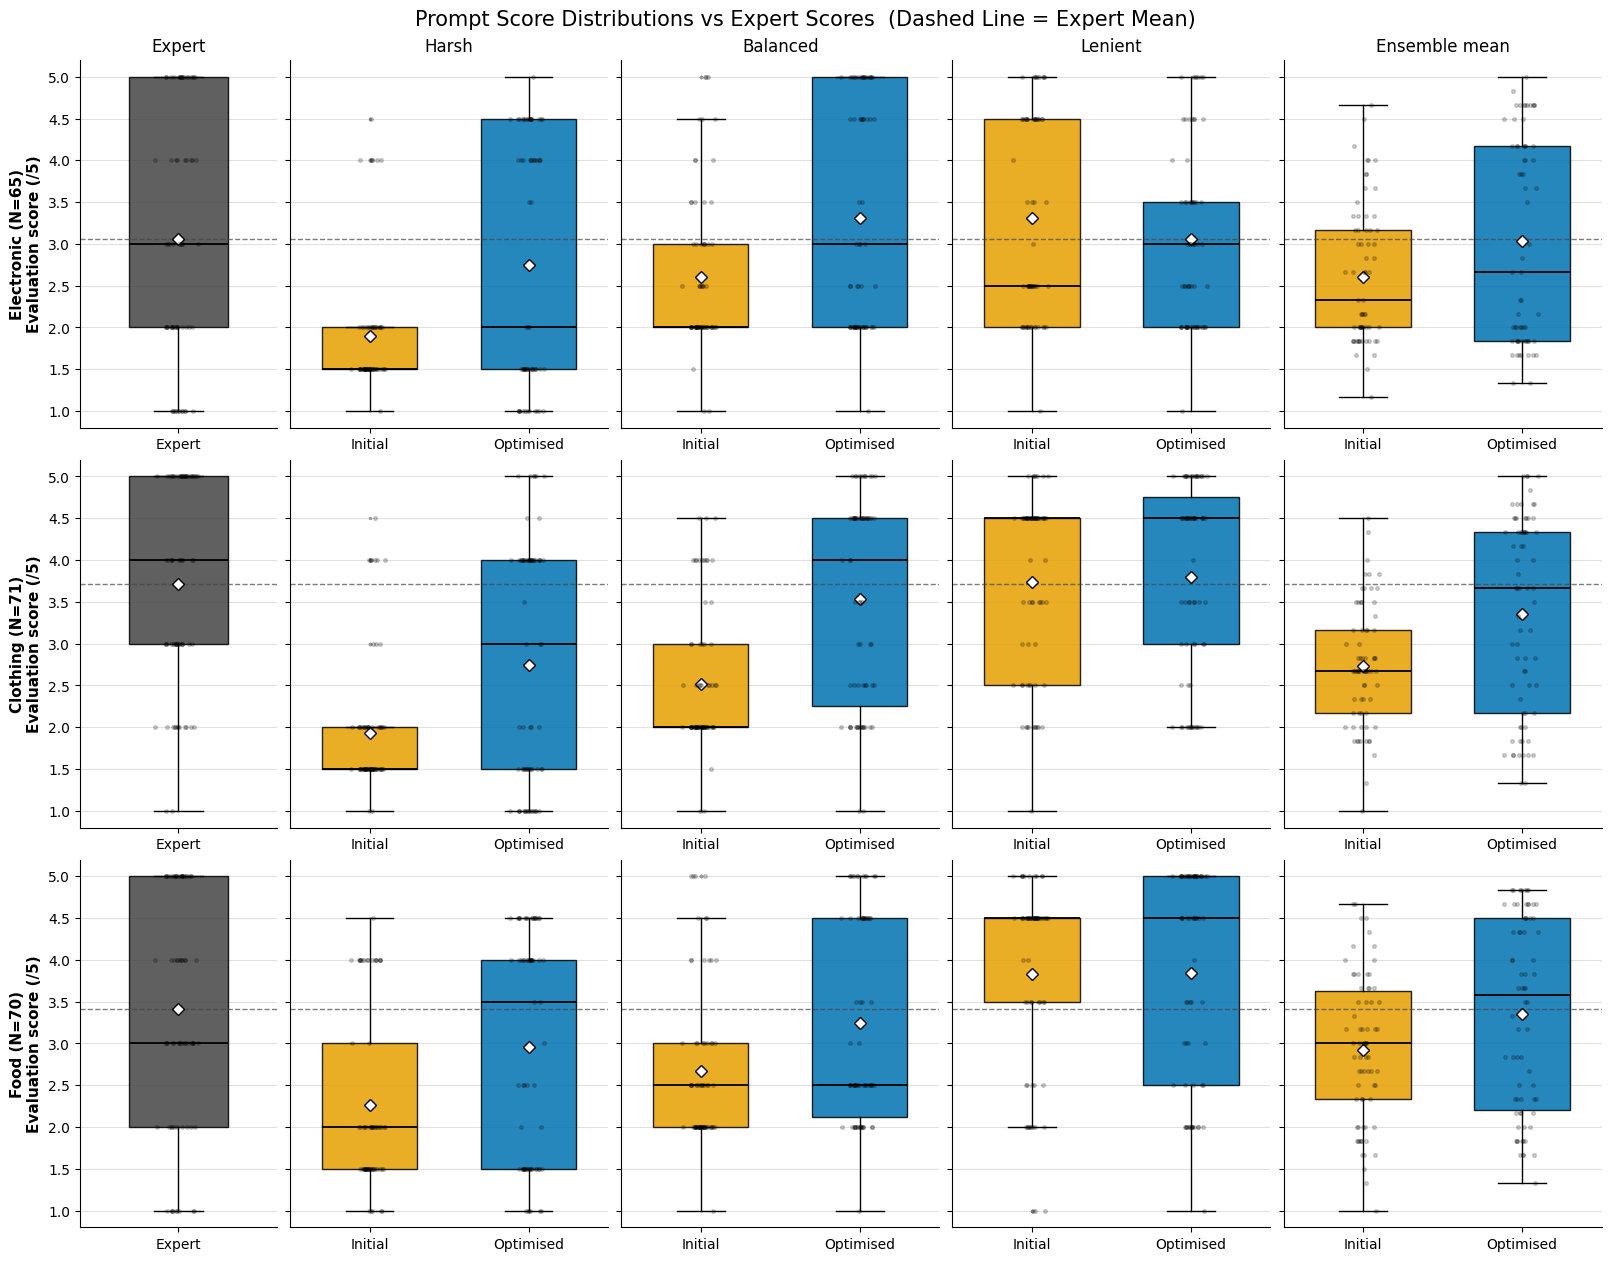

In [4]:
# 4. === Stacked distributions figure: Electronic / Clothing / Food ===
all_data = [(dom, load_scores(dom)) for dom in DOMAINS]   # ordered Electronic, Clothing, Food
panels = [("bad", "Harsh"), ("middle", "Balanced"), ("good", "Lenient"), ("ens", "Ensemble mean")]
fig, axes = plt.subplots(3, 5, figsize=(16, 12.5), sharey=True, constrained_layout=True,
                         gridspec_kw={"width_ratios": [0.62, 1, 1, 1, 1]})
for row, (dom, (true, initial, optim)) in enumerate(all_data):
    hu = np.array(true, float)
    axe = axes[row, 0]
    _box(axe, [hu], [0], [C_EXPERT], widths=0.5)
    axe.axhline(hu.mean(), color=C_EXPERT, ls="--", lw=1, alpha=0.7)
    axe.set_xticks([0], ["Expert"], fontsize=10)
    axe.set_ylabel(f"{dom.capitalize()} (N={len(true)})\nEvaluation score (/5)", fontsize=11, fontweight="bold")
    _style(axe)
    if row == 0: axe.set_title("Expert", fontsize=12)
    for ax, (key, title) in zip(axes[row, 1:], panels):
        if key == "ens":
            di = np.array([x for x in ensemble(initial) if x is not None], float)
            do = np.array([x for x in ensemble(optim) if x is not None], float)
        else:
            di = np.array([x for x in initial[key] if x is not None], float)
            do = np.array([x for x in optim[key] if x is not None], float)
        _box(ax, [di, do], [0, 1], [C_INIT, C_OPT])
        ax.axhline(hu.mean(), color=C_EXPERT, ls="--", lw=1, alpha=0.7)
        ax.set_xticks([0, 1], ["Initial", "Optimised"], fontsize=10)
        if row == 0: ax.set_title(title, fontsize=12)
        _style(ax)
fig.suptitle("Prompt Score Distributions vs Expert Scores  (Dashed Line = Expert Mean)", fontsize=15)
for ext in ("png", "pdf"):
    fig.savefig(f"{FIG_DIR}/prompt_score_distributions_all.{ext}", dpi=200, bbox_inches="tight")
print(f"saved {FIG_DIR}/prompt_score_distributions_all.png + .pdf")
plt.show()

In [5]:
# 5. === Inter-rater agreement table (Pearson r & ICC, Initial vs Optimised) ===
rows = []
for dom, (true, initial, optim) in all_data:
    for cond, data in [("initial", initial), ("optimised", optim)]:
        for a, b in PAIRS:
            m = icc_a1(data[a], data[b])
            rows.append({"domain": dom.capitalize(), "condition": cond, "pair": PAIR_LABEL[(a, b)],
                         "Pearson": m["Pearson"], "Spearman": m["Spearman"], "ICC": m["ICC"]})
pdf = pd.DataFrame(rows)

def val(dom, cond, pair, metric):
    return pdf[(pdf.domain == dom) & (pdf.condition == cond) & (pdf.pair == pair)][metric].iloc[0]

doms = [d.capitalize() for d in DOMAINS]
pairs = [PAIR_LABEL[p] for p in PAIRS]

# --- LaTeX (needs \usepackage{booktabs,multirow}) ---
L = [r"\begin{tabular}{llcccc}", r"\toprule",
     r"Domain & Rater pair & \multicolumn{2}{c}{Pearson $r$} & \multicolumn{2}{c}{ICC (abs. agr.)} \\",
     r"\cmidrule(lr){3-4}\cmidrule(lr){5-6}",
     r" & & Initial & Optimised & Initial & Optimised \\", r"\midrule"]
for di, dom in enumerate(doms):
    for k, pair in enumerate(pairs):
        head = rf"\multirow{{4}}{{*}}{{{dom}}}" if k == 0 else ""
        pi, po = val(dom, "initial", pair, "Pearson"), val(dom, "optimised", pair, "Pearson")
        ii, io = val(dom, "initial", pair, "ICC"), val(dom, "optimised", pair, "ICC")
        L.append(rf"{head} & {pair} & {pi:.2f} & \textbf{{{po:.2f}}} & {ii:.2f} & \textbf{{{io:.2f}}} \\")
    mpi = np.mean([val(dom, "initial", p, "Pearson") for p in pairs])
    mpo = np.mean([val(dom, "optimised", p, "Pearson") for p in pairs])
    mii = np.mean([val(dom, "initial", p, "ICC") for p in pairs])
    mio = np.mean([val(dom, "optimised", p, "ICC") for p in pairs])
    L.append(r"\cmidrule(lr){2-6}")
    L.append(rf" & \textit{{Mean}} & \textit{{{mpi:.2f}}} & \textit{{{mpo:.2f}}} & \textit{{{mii:.2f}}} & \textit{{{mio:.2f}}} \\")
    L.append(r"\midrule" if di < len(doms) - 1 else r"\bottomrule")
L.append(r"\end{tabular}")
with open(f"{OUT_DIR}/interrater_pairwise_table.tex", "w") as f:
    f.write("\n".join(L) + "\n")
pdf.to_csv(f"{OUT_DIR}/interrater_pairwise.csv", index=False)

# --- readable preview ---
show = pdf.pivot_table(index=["domain", "pair"], columns="condition",
                       values=["Pearson", "ICC"]).round(2)
print("Inter-rater agreement (Initial vs Optimised):")
print(show)
print(f"\nwrote {OUT_DIR}/interrater_pairwise_table.tex + interrater_pairwise.csv")

Inter-rater agreement (Initial vs Optimised):
                                ICC           Pearson          
condition                   initial optimised initial optimised
domain     pair                                                
Clothing   Balanced–Lenient    0.21      0.76    0.38      0.78
           Harsh–Balanced      0.32      0.59    0.40      0.70
           Harsh–Lenient       0.16      0.58    0.45      0.79
Electronic Balanced–Lenient    0.50      0.79    0.62      0.82
           Harsh–Balanced      0.33      0.81    0.44      0.88
           Harsh–Lenient       0.27      0.73    0.56      0.79
Food       Balanced–Lenient    0.33      0.58    0.54      0.64
           Harsh–Balanced      0.40      0.67    0.44      0.69
           Harsh–Lenient       0.31      0.66    0.61      0.82

wrote output/interrater_pairwise_table.tex + interrater_pairwise.csv
